In [1]:
result_path = '/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/two_talker_pilot_v01/'
exp_manifest_path = '/om2/user/rphess/Auditory-Attention/'

In [2]:
!hostname

node033


In [3]:
import pickle as pkl
import pandas as pd
import numpy as np
from pathlib import Path

In [4]:
results = list(Path(result_path).glob('*.csv'))
manifests = list(Path(exp_manifest_path).glob('*pilot_exp.pkl'))

In [5]:
manifests

[PosixPath('/om2/user/rphess/Auditory-Attention/ian_pilot_exp.pkl'),
 PosixPath('/om2/user/rphess/Auditory-Attention/preston_pilot_exp.pkl')]

In [6]:
with open(manifests[1], 'rb') as f:
    exp_manifest = pkl.load(f)

In [47]:
x, y = zip(*target_loc)

In [50]:
dfs = []

for result_csv in results:
    part_id = result_csv.stem 
    # manifest = 
    with open(f"/om2/user/rphess/Auditory-Attention/{part_id}_exp.pkl", 'rb') as f:
        exp_manifest = pkl.load(f)
    exp_results = pd.read_csv(result_csv)
    trials = exp_results[exp_results['trial_type'] == 'dictionary-text']
    trials.reset_index(inplace=True)

    trials = trials.drop(['index', 'Unnamed: 0', 'response_str', 'trial_type', 'internal_node_id', 'stimulus'], axis=1)

    target_loc = []
    distractor_loc = []
    sex_cond = []
    crossed = []
    azim_delta = []
    elev_delta = []
    distractor_word = []
    for block in exp_manifest.values():
        for trial in block.values():
            target_loc.append(trial['target_loc'])
            distractor_loc.append(trial['distractor_loc'])
            sex_cond.append(trial['sex_cond'])
            crossed.append(trial['crossed'])
            azim_delta.append(trial['azim_delta'])
            elev_delta.append(trial['elev_delta'])
            distractor_word.append(trial['distractor_word'])

    trials['target_azim'], trials['target_elev']= zip(*target_loc)
    trials['distractor_azim'], trials['distractor_elev'] = zip(*distractor_loc)
    trials['sex_cond'] = sex_cond
    trials['crossed'] = crossed
    trials['azim_delta'] = azim_delta
    trials['elev_delta'] = elev_delta
    trials['distractor_word'] = distractor_word
    trials['part_id'] = part_id
    dfs.append(trials)
results_df = pd.concat(dfs)

In [51]:
results_df['gender_cond'] = results_df['sex_cond']

In [52]:
def same_diff_sex(string):
    target, distractor = string.split('_')
    if target == distractor:
        return 'same'
    else:
        return 'different'
results_df['sex_cond'] = results_df['sex_cond'].apply(same_diff_sex)

In [53]:
results_df['correct'] = results_df['correct'].astype('float')

In [22]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

## Accuracy by azimuth (average over elevation)

(0.5, 1.0)

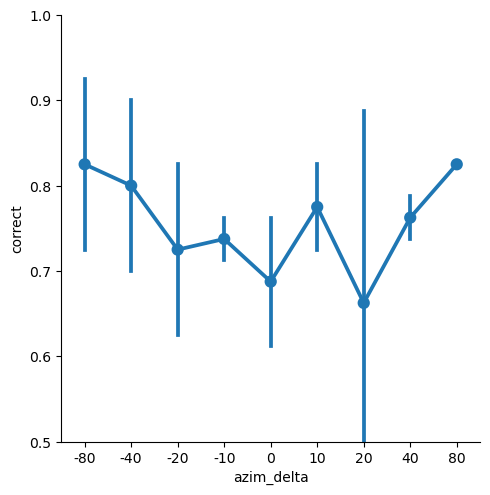

In [24]:
azim_summary_df = results_df.groupby(["part_id", "azim_delta"]).correct.mean().reset_index()
sns.catplot(data=azim_summary_df, x='azim_delta', y='correct', kind='point', errorbar=('se', 2))
plt.ylim(.5, 1)

(0.0, 1.0)

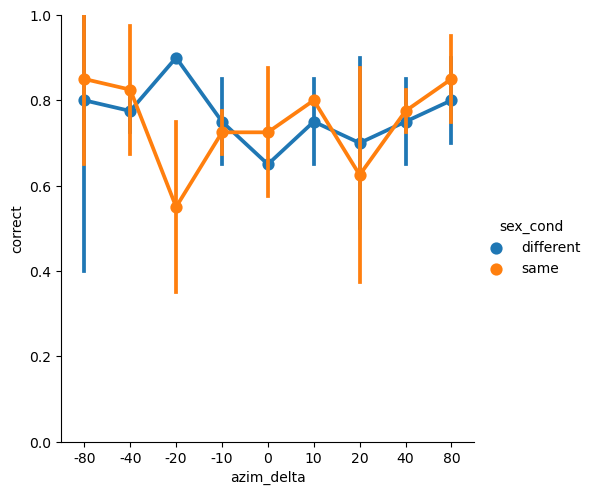

In [25]:
azim_summary_df = results_df.groupby(["part_id", "azim_delta", "sex_cond"]).correct.mean().reset_index()
sns.catplot(data=azim_summary_df, x='azim_delta', y='correct', kind='point', hue='sex_cond', errorbar=('se', 2))
plt.ylim(0, 1)

#### look at 0 elevation case 

(0.5, 1.0)

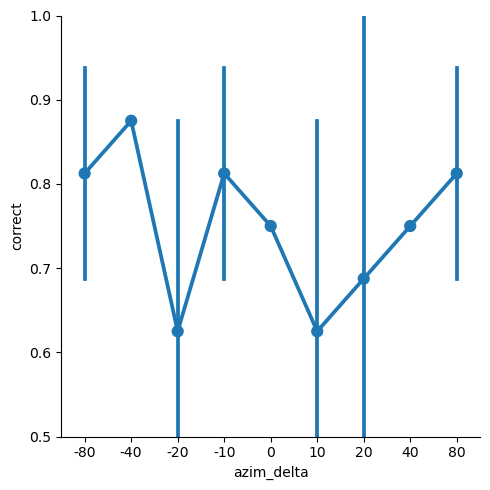

In [27]:
azim_summary_df = results_df[results_df.elev_delta == 0 ].groupby(["part_id", "azim_delta"]).correct.mean().reset_index()
sns.catplot(data=azim_summary_df, x='azim_delta', y='correct', kind='point', errorbar=('se',2))
plt.ylim(.5, 1)

## Accuracy by elevation (average over azimuth)

(0.5, 1.0)

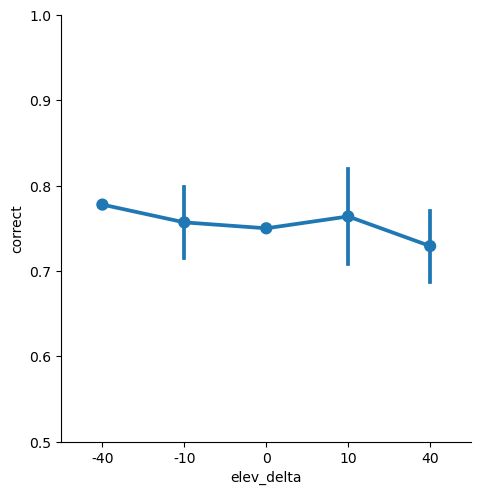

In [29]:
elev_summary_df = results_df.groupby(["part_id", "elev_delta"]).correct.mean().reset_index()
sns.catplot(data=elev_summary_df, x='elev_delta', y='correct', kind='point', errorbar=('se',2))
plt.ylim(0.5,1)

(0.5, 1.0)

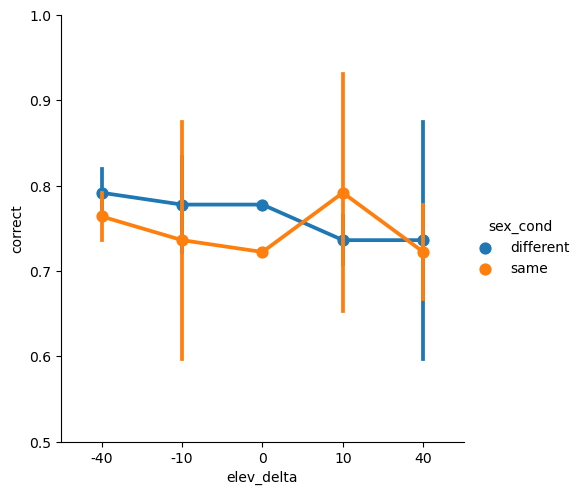

In [31]:
elev_summary_df = results_df.groupby(["part_id", "elev_delta", "sex_cond"]).correct.mean().reset_index()
sns.catplot(data=elev_summary_df, x='elev_delta', y='correct', kind='point', hue = "sex_cond", errorbar=('se',2))
plt.ylim(0.5,1)

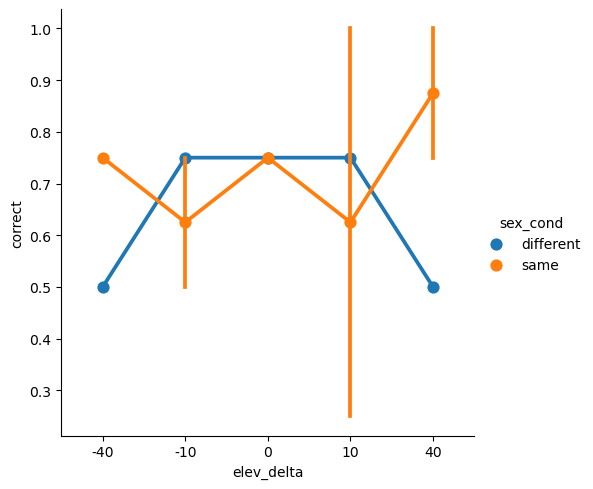

In [38]:
elev_summary_df = results_df[results_df.azim_delta ==0 ].groupby(["part_id",  "elev_delta", "sex_cond"]).correct.mean().reset_index()
sns.catplot(data=elev_summary_df, x='elev_delta', y='correct', kind='point',
             hue='sex_cond',  errorbar=('se'))
# plt.ylim(0.5,1)

## Across hemifield 

In [40]:
results_df[results_df.crossed == True]

,rt,response,correct_response,trial_num,trial_index,time_elapsed,correct,n_correct,n_incorrect,target_loc,distractor_loc,sex_cond,crossed,azim_delta,elev_delta,distractor_word,part_id,gender_cond
25,16511,death,those,25.0,50,323197,0.0,22.0,4.0,"(40, 30)","(-40, 30)",same,True,-80,0,islands,preston_pilot,female_female
30,8376,novel,novel,30.0,60,390123,1.0,26.0,5.0,"(50, 0)","(-30, 0)",different,True,-80,0,shows,preston_pilot,female_male
31,12096,provide,provide,31.0,62,403491,1.0,27.0,5.0,"(-30, 40)","(10, 0)",same,True,40,-40,birds,preston_pilot,female_female
38,9791,across,across,38.0,76,495580,1.0,32.0,7.0,"(30, 30)","(-50, 40)",same,True,-80,10,married,preston_pilot,male_male
39,20807,support,support,39.0,78,519329,1.0,33.0,7.0,"(10, 20)","(-70, -20)",same,True,-80,-40,government,preston_pilot,female_female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,8276,critics,alone,328.0,476,3027613,0.0,177.0,62.0,"(-60, 30)","(20, -10)",different,True,80,-40,information,ian_pilot,female_male
338,8140,letters,written,338.0,496,3155618,0.0,184.0,65.0,"(-50, -20)","(30, -20)",same,True,80,0,birds,ian_pilot,female_female
342,8758,research,research,342.0,504,3198182,1.0,187.0,66.0,"(10, 40)","(-30, 0)",different,True,-40,-40,between,ian_pilot,female_male
346,10037,recently,recently,346.0,512,3234930,1.0,191.0,66.0,"(-20, 20)","(60, -20)",same,True,80,-40,exist,ian_pilot,male_male


(0.5, 1.0)

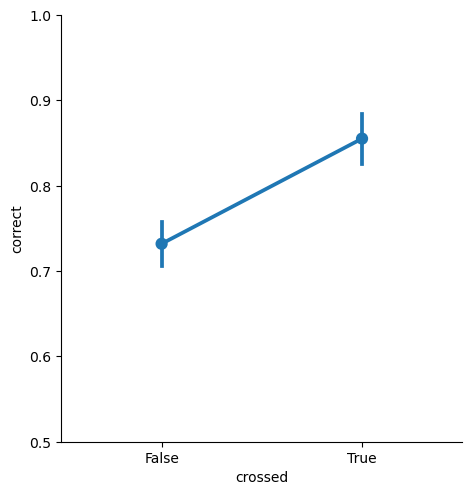

In [ ]:

crossed_summary_df = results_df.groupby(["part_id", "crossed", "sex_cond"]).correct.mean().reset_index()

sns.catplot(data=crossed_summary_df, x='crossed', y='correct', kind='point', errorbar=('se'))
plt.ylim(.5, 1)

(0.5, 1.0)

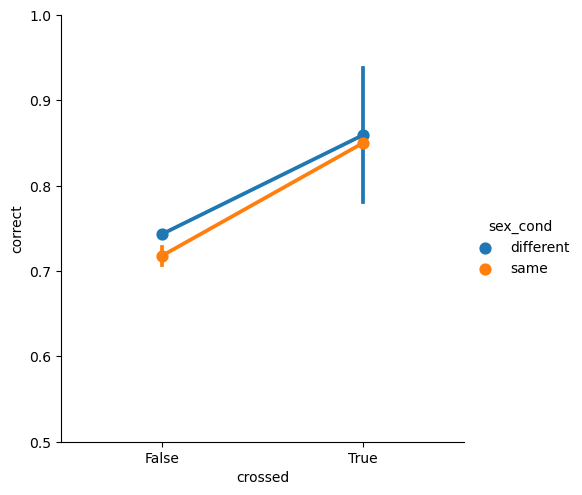

In [55]:

crossed_summary_df = results_df.groupby(["part_id", "crossed", "sex_cond"]).correct.mean().reset_index()

sns.catplot(data=crossed_summary_df, x='crossed', y='correct', kind='point', hue='sex_cond', errorbar=('se'))
plt.ylim(.5, 1)

In [57]:
results_df['abs_target_azim'] = results_df['target_azim'].abs()
results_df['target_on_periph'] = results_df['abs_target_azim'] >= 30

In [63]:
results_df

,rt,response,correct_response,trial_num,trial_index,time_elapsed,correct,n_correct,n_incorrect,target_azim,...,distractor_elev,sex_cond,crossed,azim_delta,elev_delta,distractor_word,part_id,gender_cond,abs_target_azim,target_on_periph
0,33746,students,students,0.0,0,33748,1.0,1.0,0.0,30,...,40,same,False,40,40,twenty,preston_pilot,male_male,30,True
1,10490,appear,appear,1.0,2,46805,1.0,2.0,0.0,-20,...,20,different,False,0,10,black,preston_pilot,male_female,20,False
2,9338,travel,travel,2.0,4,57269,1.0,3.0,0.0,-40,...,-10,different,False,-20,-40,worked,preston_pilot,female_male,40,True
3,10722,complete,complete,3.0,6,69002,1.0,4.0,0.0,0,...,20,different,False,40,10,complex,preston_pilot,male_female,0,False
4,8479,hundred,groups,4.0,8,78705,0.0,4.0,1.0,-90,...,20,different,False,80,40,players,preston_pilot,female_male,90,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,7310,living,living,355.0,530,3327958,1.0,198.0,68.0,40,...,20,different,False,40,40,entered,ian_pilot,male_female,40,True
356,9660,nothing,nothing,356.0,532,3338287,1.0,199.0,68.0,70,...,-10,different,False,-20,10,forward,ian_pilot,female_male,70,True
357,25705,reach,released,357.0,534,3365303,0.0,199.0,69.0,-90,...,-10,same,False,40,10,function,ian_pilot,female_female,90,True
358,7574,cover,cover,358.0,536,3373803,1.0,200.0,69.0,60,...,0,same,True,-80,0,least,ian_pilot,male_male,60,True


(0.5, 1.0)

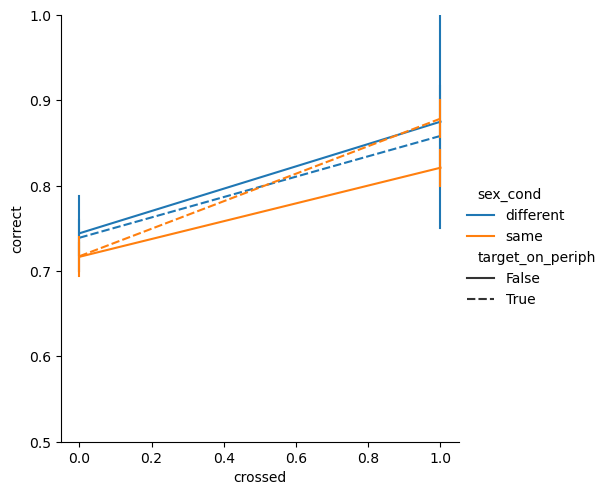

In [64]:

crossed_summary_df = results_df.groupby(["part_id", "crossed", "sex_cond", "target_on_periph"]).correct.mean().reset_index()

sns.relplot(data=crossed_summary_df, x='crossed', y='correct', kind='line', err_style='bars',
             hue='sex_cond', style='target_on_periph',  errorbar=('se'))
plt.ylim(.5, 1)


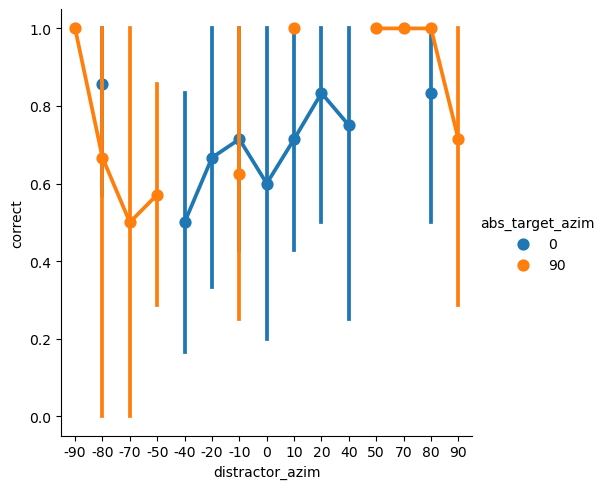

In [70]:
## Plot by position 

to_plot = results_df[results_df.abs_target_azim.isin([0, 90])]
sns.catplot(data=to_plot, x='distractor_azim', y='correct', kind='point', hue='abs_target_azim',)

